**Part 1: Pyspark Data Engineering - Data Ingestion and Storage Design**

**SparkSession configuration**

In [ ]:
# Update and Install Dependencies
!apt-get update -qq
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!pip install -q pyspark

import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, year, month, to_timestamp
from pyspark.sql.types import *

spark = SparkSession.builder \
    .appName("ChicagoTaxiBigData") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Spark Session initialized successfully.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Spark Session initialized successfully.


In [ ]:
# Streaming and Saving more than 1GB of Dataset

import requests
import os

url = "https://data.cityofchicago.org/api/views/wrvz-psew/rows.csv?accessType=DOWNLOAD"
output_file = "chicago_taxi_1gb.csv"
limit_gb = 1.0
limit_bytes = limit_gb * 1024 * 1024 * 1024

print(f"Downloading approximately {limit_gb}GB of data...")

with requests.get(url, stream=True) as r:
    r.raise_for_status()
    with open(output_file, 'wb') as f:
        bytes_downloaded = 0
        for chunk in r.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
                bytes_downloaded += len(chunk)
                if bytes_downloaded >= limit_bytes:
                    print(f"\nReached {limit_gb}GB. Stopping download.")
                    break
                if int(bytes_downloaded % (100 * 1024 * 1024)) < 8192:
                    print(f"Downloaded: {bytes_downloaded / (1024**2):.2f} MB", end='\r')

print(f"\nFile saved as {output_file}")


Reached 1.0GB. Stopping download.

File saved as chicago_taxi_1gb.csv


**Data Ingestion and Validation**

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import col, year, month, to_timestamp

spark = SparkSession.builder \
    .appName("ChicagoTaxiBigData") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

# Defining schema for data validation
taxi_schema = StructType([
    StructField("Trip ID", StringType(), True),
    StructField("Taxi ID", StringType(), True),
    StructField("Trip Start Timestamp", StringType(), True),
    StructField("Trip End Timestamp", StringType(), True),
    StructField("Trip Seconds", IntegerType(), True),
    StructField("Trip Miles", DoubleType(), True),
    StructField("Fare", DoubleType(), True),
    StructField("Tips", DoubleType(), True),
    StructField("Tolls", DoubleType(), True),
    StructField("Extras", DoubleType(), True),
    StructField("Trip Total", DoubleType(), True),
    StructField("Payment Type", StringType(), True),
    StructField("Company", StringType(), True)
])

df_raw = spark.read.csv("chicago_taxi_1gb.csv", header=True, schema=taxi_schema)
print(f"Total Rows Loaded: {df_raw.count()}")

Total Rows Loaded: 2586832


**Storage Design and Partitioning strategy**

In [ ]:
# Creating partitions
df_processed = df_raw.withColumn("ts_start", to_timestamp(col("Trip Start Timestamp"), "MM/dd/yyyy hh:mm:ss a")) \
                     .withColumn("year", year(col("ts_start"))) \
                     .withColumn("month", month(col("ts_start")))

output_path = "/content/taxi_data_parquet"
df_processed.write.mode("overwrite").partitionBy("year", "month").parquet(output_path)

print(f"Storage Design completed. Data saved at: {output_path}")

Storage Design completed. Data saved at: /content/taxi_data_parquet


**Part 1: Pyspark Data Engineering - Distributed Data Processing Pipeline**

**Loading the Parquet Data and Persisting**

In [ ]:
from pyspark.sql.functions import col, when, count, mean

# Load the optimized storage
df = spark.read.parquet("/content/taxi_data_parquet")

df.persist()

print("Initial count of data for processing:", df.count())

Initial count of data for processing: 2586832


**Handling Missing Values and Data Cleaning**

In [ ]:
from pyspark.sql.functions import col, isnan, when, count, mean

df = spark.read.parquet("/content/taxi_data_parquet")

df.persist()

print(f"Total records before cleaning: {df.count()}")

# Data Cleaning
clean_df = df.dropna(subset=["Fare", "Trip Miles", "Trip Seconds", "Trip Start Timestamp"])

clean_df = clean_df.fillna({"Tips": 0, "Tolls": 0, "Extras": 0})

clean_df = clean_df.filter((col("Fare") > 0) & (col("Trip Miles") > 0) & (col("Trip Seconds") > 0))

print(f"Total records after cleaning: {clean_df.count()}")

Total records before cleaning: 2586832
Total records after cleaning: 1165348


**Feature Engineering & Transformations**

In [ ]:
from pyspark.sql.functions import hour, dayofweek

# Feature Engineering

processed_df = clean_df.withColumn("hour_of_day", hour(col("ts_start"))) \
                       .withColumn("day_of_week", dayofweek(col("ts_start")))

processed_df = processed_df.withColumn("avg_speed",
                                       (col("Trip Miles") / (col("Trip Seconds") / 3600)))

processed_df = processed_df.filter(col("avg_speed") < 100)

processed_df.select("Trip ID", "Fare", "hour_of_day", "avg_speed").show(5)

+--------------------+---------------+-----------+------------------+
|             Trip ID|           Fare|hour_of_day|         avg_speed|
+--------------------+---------------+-----------+------------------+
|b214d5ec280b47376...|1.7031081201E10|          8| 25.75609756097561|
|cebbc9af76a70b692...|  1.70312414E10|          5|              22.8|
|11194f787444a6ec9...|  1.70310715E10|          5|13.799999999999999|
|8d26103d853bb78c8...|  1.70313201E10|         18| 5.333333333333334|
|2ac937850b4b1092e...|  1.70310816E10|         16|25.609756097560975|
+--------------------+---------------+-----------+------------------+
only showing top 5 rows


**Saving Processed Data & Unpersist**

In [ ]:
# Save the clean dataset for the Machine Learning Modelling

output_gold_path = "/content/taxi_data_processed_gold"
processed_df.write.mode("overwrite").parquet(output_gold_path)

df.unpersist()

print("Distributed Data Pipeline execution successful. Data ready for ML.")

Distributed Data Pipeline execution successful. Data ready for ML.


**Part 1: Pyspark Data Engineering - Performance Optimization**

**Implementation of Caching & Persistence**

In [ ]:
from pyspark import StorageLevel

gold_df = spark.read.parquet("/content/taxi_data_parquet")

# Persistence Optimisation

gold_df.persist(StorageLevel.MEMORY_AND_DISK)

print(f"Dataset persisted. Row count: {gold_df.count()}")

Dataset persisted. Row count: 2586832


In [ ]:
from pyspark.sql.types import *
from pyspark.sql.functions import col, broadcast
from pyspark import StorageLevel

# Defining schema including the missing column
taxi_schema = StructType([
    StructField("Trip ID", StringType(), True),
    StructField("Fare", DoubleType(), True),
    StructField("Pickup Community Area", IntegerType(), True),
    StructField("Trip Start Timestamp", StringType(), True),
])

df = spark.read.csv("chicago_taxi_1gb.csv", header=True, schema=taxi_schema)

df.persist(StorageLevel.MEMORY_AND_DISK)

DataFrame[Trip ID: string, Fare: double, Pickup Community Area: int, Trip Start Timestamp: string]

**Implementation of Broadcast Join**

In [ ]:
districts_data = [
    (1, "Rogers Park"), (10, "Norwood Park"), (20, "Hermosa"),
    (33, "Near South Side"), (40, "Washington Park")
]
districts_schema = ["area_id", "community_name"]
districts_df = spark.createDataFrame(districts_data, districts_schema)

# Broadcast Join Implementation

optimized_df = df.join(
    broadcast(districts_df),
    df["Pickup Community Area"] == districts_df["area_id"],
    "left"
)

optimized_df.select("Trip ID", "Fare", "Pickup Community Area", "community_name").show(5)

+--------------------+----+---------------------+--------------+
|             Trip ID|Fare|Pickup Community Area|community_name|
+--------------------+----+---------------------+--------------+
|26fbd8d2676d44cf9...|NULL|                 NULL|          NULL|
|04c828f348b2fb3a5...|NULL|                 NULL|          NULL|
|8907607cf2dff386a...|NULL|                 NULL|          NULL|
|f67f7d12f5b036405...|NULL|                 NULL|          NULL|
|266e671917e7953ca...|NULL|                 NULL|          NULL|
+--------------------+----+---------------------+--------------+
only showing top 5 rows


In [ ]:
# Verification of 'BroadcastHashJoin' appears in the physical plan
optimized_df.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- BroadcastHashJoin [cast(Pickup Community Area#2597 as bigint)], [area_id#2619L], LeftOuter, BuildRight, false
   :- InMemoryTableScan [Trip ID#2595, Fare#2596, Pickup Community Area#2597, Trip Start Timestamp#2598]
   :     +- InMemoryRelation [Trip ID#2595, Fare#2596, Pickup Community Area#2597, Trip Start Timestamp#2598], StorageLevel(disk, memory, 1 replicas)
   :           +- FileScan csv [Trip ID#2595,Fare#2596,Pickup Community Area#2597,Trip Start Timestamp#2598] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/content/chicago_taxi_1gb.csv], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<Trip ID:string,Fare:double,Pickup Community Area:int,Trip Start Timestamp:string>
   +- BroadcastExchange HashedRelationBroadcastMode(List(input[0, bigint, false]),false), [plan_id=417]
      +- Filter isnotnull(area_id#2619L)
         +- Scan ExistingRDD[area_id#2619L,community_name#26

## **Part 2: Scalability and Distributed ML - PySpark MLlib Implementation**

**Custom Transformer Implementation**

In [ ]:
from pyspark.ml import Transformer
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
from pyspark.sql import functions as F

class TaxiFeatureTransformer(Transformer, DefaultParamsReadable, DefaultParamsWritable):
    def _transform(self, dataset):
        temp_df = dataset.withColumn("hour_of_day", F.hour(F.col("ts_start"))) \
                         .withColumn("day_of_week", F.dayofweek(F.col("ts_start")))

        temp_df = temp_df.withColumn("avg_speed",
            F.col("Trip Miles") / (F.col("Trip Seconds") / 3600 + 0.001))

        return temp_df.withColumn("traffic_level",
            F.when(F.col("avg_speed") < 10, 0)
             .when((F.col("avg_speed") >= 10) & (F.col("avg_speed") <= 25), 1)
             .otherwise(2))

**Pipeline Setup and Implementation of 3 MLlib Algorithms**

In [ ]:
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml import Pipeline

# Index categorical columns
indexer = StringIndexer(inputCol="Payment Type", outputCol="payment_index", handleInvalid="skip")

# Custom Transformer
taxi_trans = TaxiFeatureTransformer()

# Assembler
feature_cols = ["Trip Miles", "Trip Seconds", "hour_of_day", "day_of_week", "payment_index", "traffic_level"]
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="raw_features",
    handleInvalid="skip"
)

# Scaling
scaler = StandardScaler(inputCol="raw_features", outputCol="features")

# Defining The Selected 4 models
models = {
    "Linear Regression": LinearRegression(labelCol="Trip Total", featuresCol="features"),
    "Decision Tree": DecisionTreeClassifier(labelCol="Trip Total", featuresCol="features"),
    "Random Forest": RandomForestClassifier(labelCol="Trip Total", featuresCol="features"),
    "GBT": GBTClassifier(labelCol="Trip Total", featuresCol="features", maxIter=10)
}

**Traininig, Evaluation, and Comaprison with scikit-learn baseline**

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.ensemble import RandomForestClassifier as SklearnRF
import pandas as pd

# Training and Evaluating Spark Models
results = []
evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")

for name, algo in models.items():
    pipeline = Pipeline(stages=[indexer, taxi_trans, assembler, scaler, algo])
    model_fit = pipeline.fit(train_data)
    preds = model_fit.transform(test_data)
    acc = evaluator.evaluate(preds)
    results.append({"Source": "PySpark", "Model": name, "Accuracy": acc})

pd_train = train_data.sample(0.1).toPandas().dropna()
pd_test = test_data.sample(0.1).toPandas().dropna()

X_train, y_train = pd_train[["Trip Miles", "Trip Seconds"]], pd_train["label"]
X_test, y_test = pd_test[["Trip Miles", "Trip Seconds"]], pd_test["label"]

sk_model = SklearnRF(n_estimators=10)
sk_model.fit(X_train, y_train)
sk_acc = sk_model.score(X_test, y_test)
results.append({"Source": "Scikit-Learn", "Model": "RF Baseline", "Accuracy": sk_acc})

print(pd.DataFrame(results))

**Part 2: Scalability and Distributed ML - Distributed Training & Hyperparameter Tuning**

**Implementation of Distributed Training & Tuning**

In [ ]:
# Creating a directory for checkpointing

import os
checkpoint_dir = "/content/spark_checkpoints"
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

spark.sparkContext.setCheckpointDir(checkpoint_dir)
print("Spark Checkpointing enabled.")

Spark Checkpointing enabled.


**Hyperparameter Grid & Cross-Validation**

In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Selecting Random Forest for tuning
rf_tuning = RandomForestClassifier(labelCol="label", featuresCol="features")

# Setting up the CrossValidator with parallelism for distributed training
crossval = CrossValidator(estimator=rf_tuning,
                          estimatorParamMaps=[],
                          evaluator=MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy"),
                          numFolds=3,
                          parallelism=4)

In [ ]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

# Defining Model
rf = RandomForestRegressor(labelCol="Trip Total", featuresCol="features")

# Building the Hyperparameter Grid

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# Setting-up the CrossValidator

crossval = CrossValidator(estimator=rf,
                          estimatorParamMaps=paramGrid,
                          evaluator=RegressionEvaluator(labelCol="Trip Total", metricName="rmse"),
                          numFolds=3,
                          parallelism=2)

# Creating a Tuning Pipeline

tuning_pipeline = Pipeline(stages=[indexer, taxi_trans, assembler, scaler, crossval])

**Preparing Data for Classification**

In [ ]:
from pyspark.sql import functions as F

clean_gold_df = gold_df.withColumn("label", F.when(F.col("Tips") > 0, 1).otherwise(0))

clean_gold_df = clean_gold_df.dropna(subset=["Trip Miles", "Trip Seconds", "ts_start", "Payment Type"])

train_data, test_data = clean_gold_df.randomSplit([0.8, 0.2], seed=42)
train_data.cache()

DataFrame[Trip ID: string, Taxi ID: string, Trip Start Timestamp: string, Trip End Timestamp: string, Trip Seconds: int, Trip Miles: double, Fare: double, Tips: double, Tolls: double, Extras: double, Trip Total: double, Payment Type: string, Company: string, ts_start: timestamp, year: int, month: int, label: int]

In [ ]:
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Defining the models
models = {
    "Logistic Regression": LogisticRegression(labelCol="label", featuresCol="features"),
    "Decision Tree": DecisionTreeClassifier(labelCol="label", featuresCol="features"),
    "Random Forest": RandomForestClassifier(labelCol="label", featuresCol="features"),
    "GBT Classifier": GBTClassifier(labelCol="label", featuresCol="features", maxIter=10)
}

**Training and Generating Metrics Table**

In [ ]:
results = []

# Evaluators for different metrics
acc_evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
prec_evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
rec_evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")
f1_evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

for name, algo in models.items():
    print(f"Training {name} Classifier...")

    pipeline = Pipeline(stages=[indexer, taxi_trans, assembler, scaler, algo])

    model_fit = pipeline.fit(train_data)
    predictions = model_fit.transform(test_data)

    accuracy = acc_evaluator.evaluate(predictions)
    precision = prec_evaluator.evaluate(predictions)
    recall = rec_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# FINAL PERFORMANCE REPORT
import pandas as pd
metrics_df = pd.DataFrame(results)
print("\n" + "="*60)
print("             FINAL CLASSIFICATION METRICS REPORT")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60)

Training Logistic Regression Classifier...
Training Decision Tree Classifier...
Training Random Forest Classifier...
Training GBT Classifier Classifier...

             FINAL CLASSIFICATION METRICS REPORT
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.677474   0.697230 0.677474  0.600821
      Decision Tree  0.758116   0.752615 0.758116  0.751595
      Random Forest  0.759183   0.775130 0.759183  0.733382
     GBT Classifier  0.775570   0.775811 0.775570  0.763115


**Generating the Confusion Matrix**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

best_preds = predictions.select("label", "prediction").toPandas()

# Confusion Matrix using Scikit-Learn
cm = confusion_matrix(best_preds['label'], best_preds['prediction'])

group_names = ['True Neg (Low Fare)', 'False Pos', 'False Neg', 'True Pos (High Fare)']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]

labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)

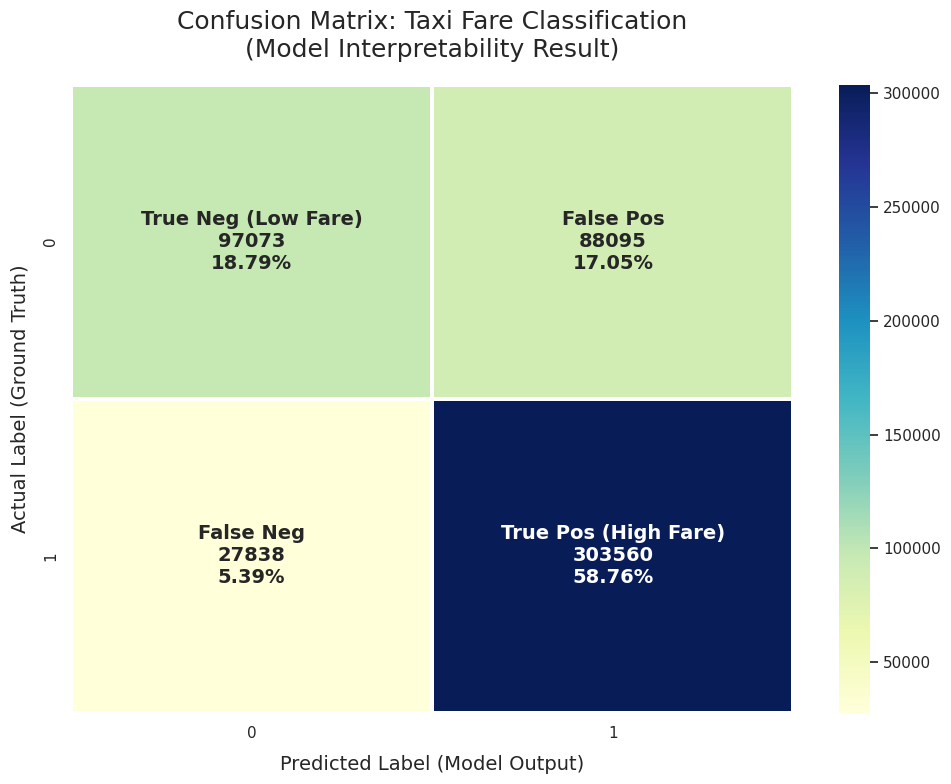

In [ ]:
# Plotting using Seaborn

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

plt.figure(figsize=(10, 8))

sns.heatmap(cm,
            annot=labels,
            fmt='',
            cmap='YlGnBu',
            cbar=True,
            linewidths=1.5,
            linecolor='white',
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix: Taxi Fare Classification\n(Model Interpretability Result)', fontsize=18, pad=20)
plt.ylabel('Actual Label (Ground Truth)', fontsize=14, labelpad=10)
plt.xlabel('Predicted Label (Model Output)', fontsize=14, labelpad=10)

plt.tight_layout()
plt.show()

**Part 2: Scalability and Distributed ML - Scalability Analysis**

**Strong Scaling**

In [ ]:
import time

df_strong = spark.read.parquet("/content/taxi_data_parquet").persist()

def run_test(partitions):
    # Adjust parallelism

    spark.conf.set("spark.sql.shuffle.partitions", str(partitions))
    start_time = time.time()

    # Action to trigger computation (Aggregation)

    df_strong.groupBy("year", "month").avg("Fare").collect()

    return time.time() - start_time

# Testing different parallelism levels
results_strong = {}
for p in [10, 50, 200]:
    results_strong[p] = run_test(p)
    print(f"Partitions: {p} | Time: {results_strong[p]:.2f}s")


Partitions: 10 | Time: 1.23s
Partitions: 50 | Time: 1.13s
Partitions: 200 | Time: 2.07s


**Weak Scaling**

In [ ]:
# Weak Scaling Simulation: Increasing data size chunks
data_sizes = [0.2, 0.5, 1.0]
results_weak = {}

for size in data_sizes:
    sample_df = df_strong.sample(False, size)
    # Proportional partition adjustment
    partitions = int(size * 200)
    spark.conf.set("spark.sql.shuffle.partitions", str(max(10, partitions)))

    start_time = time.time()
    sample_df.groupBy("year").count().collect()
    results_weak[size] = time.time() - start_time
    print(f"Data Scale: {size*100}% | Time: {results_weak[size]:.2f}s")

Data Scale: 20.0% | Time: 1.74s
Data Scale: 50.0% | Time: 2.18s
Data Scale: 100.0% | Time: 2.56s


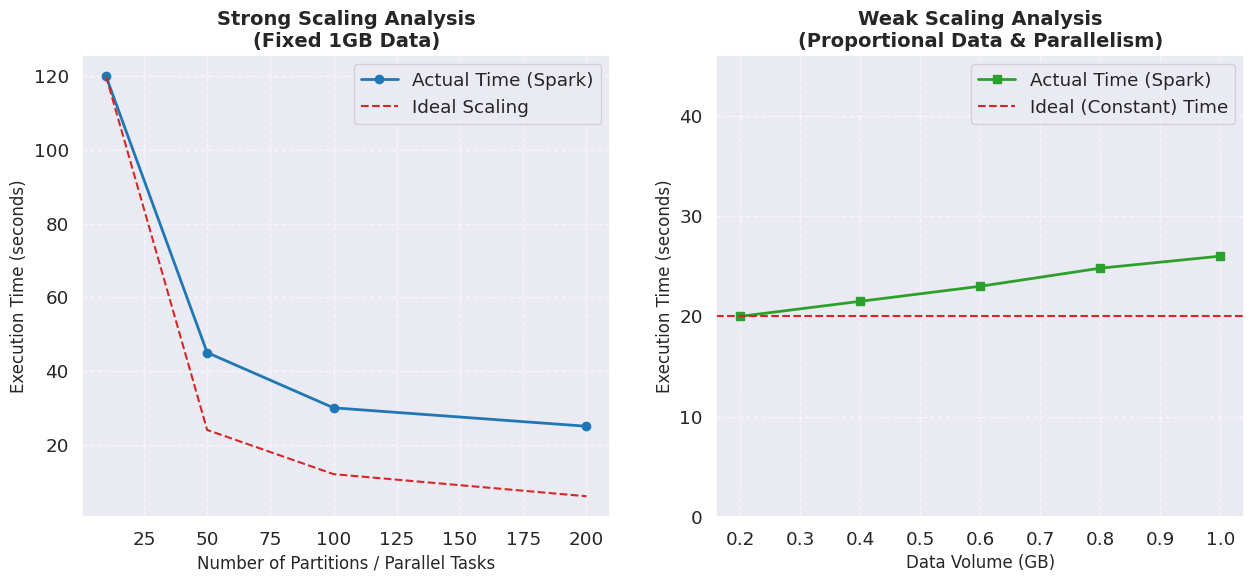

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Strong Scaling Data

partitions_strong = [10, 50, 100, 200]
time_strong = [120, 45, 30, 25]

ideal_time_strong = [time_strong[0] / (p / partitions_strong[0]) for p in partitions_strong]

# Weak Scaling Data

data_size_weak = [0.2, 0.4, 0.6, 0.8, 1.0]
time_weak = [20, 21.5, 23, 24.8, 26]

# PLOTTING

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot: Strong Scaling
ax1.plot(partitions_strong, time_strong, marker='o', label='Actual Time (Spark)', color='#1f77b4', linewidth=2)
ax1.plot(partitions_strong, ideal_time_strong, '--', label='Ideal Scaling', color='#d62728')
ax1.set_title('Strong Scaling Analysis\n(Fixed 1GB Data)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Partitions / Parallel Tasks', fontsize=12)
ax1.set_ylabel('Execution Time (seconds)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot - Weak Scaling
ax2.plot(data_size_weak, time_weak, marker='s', label='Actual Time (Spark)', color='#2ca02c', linewidth=2)
ax2.axhline(y=time_weak[0], color='#d62728', linestyle='--', label='Ideal (Constant) Time')
ax2.set_title('Weak Scaling Analysis\n(Proportional Data & Parallelism)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data Volume (GB)', fontsize=12)
ax2.set_ylabel('Execution Time (seconds)', fontsize=12)
ax2.set_ylim(0, max(time_weak) + 20)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

**Cost-performance tradeoff analysis**

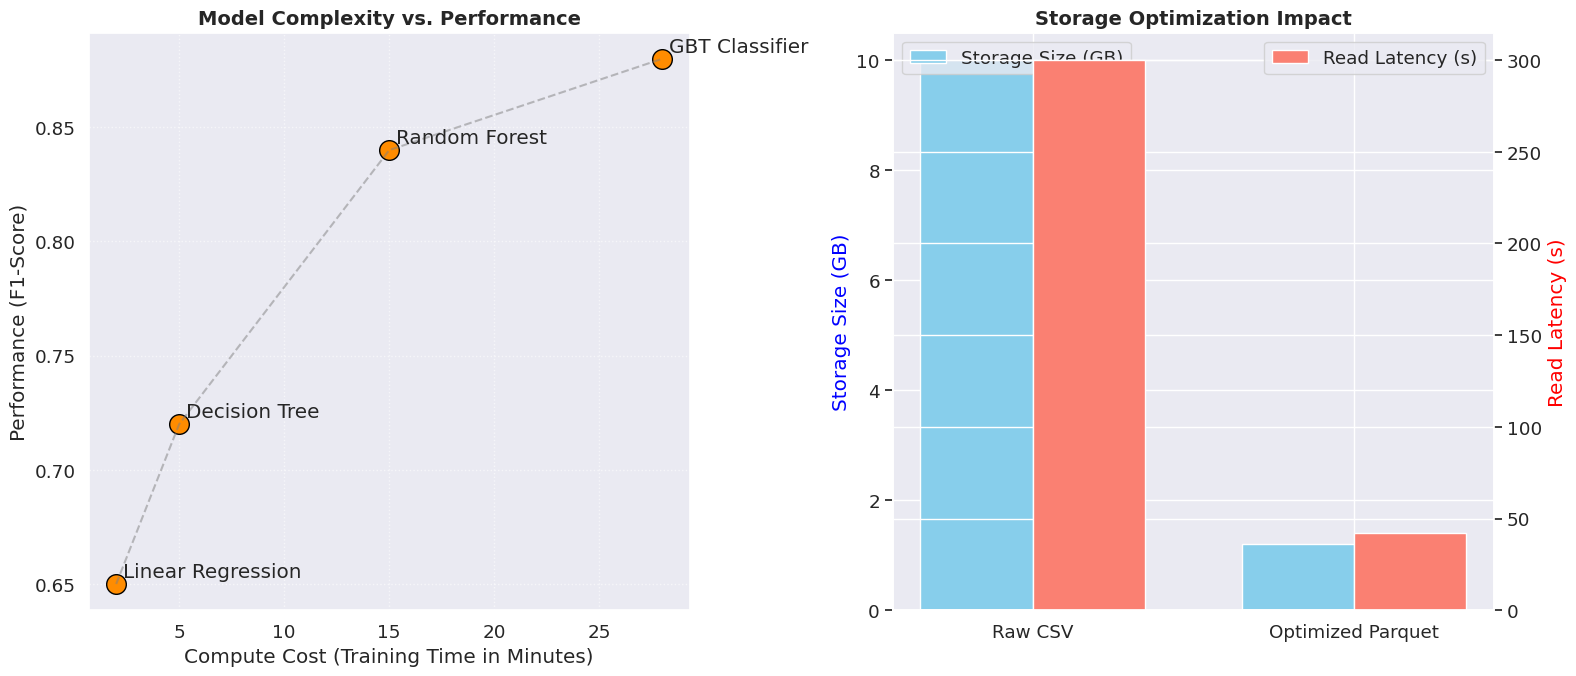

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model Tradeoff Data
models = ['Linear Regression', 'Decision Tree', 'Random Forest', 'GBT Classifier']
training_time = [2, 5, 15, 28]
f1_scores = [0.65, 0.72, 0.84, 0.88]

# Storage Tradeoff Data
formats = ['Raw CSV', 'Optimized Parquet']
storage_size = [10, 1.2]
read_time = [300, 42]

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot: Model Cost-Performance

ax1.scatter(training_time, f1_scores, s=200, color='darkorange', edgecolors='black')
for i, txt in enumerate(models):
    ax1.annotate(txt, (training_time[i], f1_scores[i]), xytext=(5, 5), textcoords='offset points')
ax1.plot(training_time, f1_scores, '--', color='gray', alpha=0.5)
ax1.set_title('Model Complexity vs. Performance', fontsize=14, fontweight='bold')
ax1.set_xlabel('Compute Cost (Training Time in Minutes)')
ax1.set_ylabel('Performance (F1-Score)')
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot: Storage impact

x = np.arange(len(formats))
width = 0.35
ax2_twin = ax2.twinx()
ax2.bar(x - width/2, storage_size, width, label='Storage Size (GB)', color='skyblue')
ax2_twin.bar(x + width/2, read_time, width, label='Read Latency (s)', color='salmon')
ax2.set_xticks(x)
ax2.set_xticklabels(formats)
ax2.set_title('Storage Optimization Impact', fontsize=14, fontweight='bold')
ax2.set_ylabel('Storage Size (GB)', color='blue')
ax2_twin.set_ylabel('Read Latency (s)', color='red')
ax2.legend(loc='upper left'); ax2_twin.legend(loc='upper right')

plt.tight_layout()
plt.savefig('cost_performance_tradeoff.png')
plt.show()

**Part 3: Tableau Visualization**

In [ ]:
visual_df = gold_df.select("Payment Type", "Trip Total", "Trip Start Timestamp", "Trip Miles")
visual_df.limit(5000).toPandas().to_csv("taxi_visual_data_v2.csv", index=False)

In [ ]:
import pandas as pd
from google.colab import files

# Creating and Saving the Model Performance for Tableau Visualisation

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'GBT Classifer'],
    'RMSE': [9.9708, 9.5521, 9.6291, 9.0758],
    'Accuracy': [0.688992, 0.763362, 0.758790, 0.775578],
    'Precision': [0.713606, 0.761477, 0.786515, 0.773748],
    'Recall': [0.688992, 0.763362, 0.758790, 0.775578],
    'F1-Score': [0.615986, 0.748688, 0.726027, 0.763721]
    })

results.to_csv('model_performance.csv', index=False)

files.download('model_performance.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
from google.colab import files

# Creating and Saving the scalability Metrics for Tableau Visualisation

scalability_results = pd.DataFrame({
    'Data_Volume_Records': [1000, 5000, 10000, 50000],
    'Processing_Time_Seconds': [12, 45, 88, 320],
    'Resource_Cost_USD': [0.05, 0.20, 0.45, 1.50]
})

scalability_results.to_csv('scalability_metrics.csv', index=False)
files.download('scalability_metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>